In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from pathlib import Path

KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

In [3]:
# look at first few rows
train.head(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
# size of dataset
print(train.shape)
print(test.shape)
print(ss.shape)

(630000, 15)
(270000, 14)
(270000, 2)


(array([282454.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 347546.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

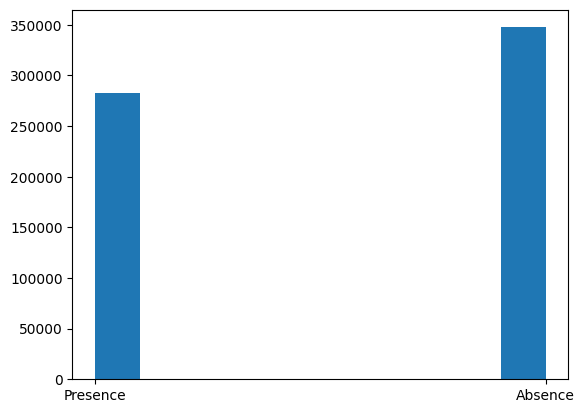

In [5]:
# target distribution
plt.hist(train['Heart Disease'])

In [6]:
target = train['Heart Disease']
print(target.value_counts())

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

# Feature Exploration and Data type 

### Descriptions from the original dataset


- **Sex**  
  - Gender of the patient (1 = Male, 0 = Female).  
  - Binary categorical; keep as 0/1 int or bool (optionally cast to categorical for EDA).

- **Chest pain type**  
  - 1 = Typical angina; 2 = Atypical angina; 3 = Non-anginal pain; 4 = Asymptomatic.  
  - Ordinal categorical; codes have a natural order, keep as small int or ordered categorical.

- **BP**  
  - Resting blood pressure (mm Hg).  
  - Continuous numeric feature.

- **Cholesterol**  
  - Serum cholesterol level (mg/dL).  
  - Continuous numeric feature.

- **FBS over 120**  
  - Fasting blood sugar > 120 mg/dL (1 = True, 0 = False).  
  - Binary categorical; 0/1 int or bool.

- **EKG results**  
  - 0 = Normal; 1 = ST-T wave abnormality; 2 = Left ventricular hypertrophy.  
  - Ordinal categorical; increasing abnormality, so the order is meaningful.

- **Max HR**  
  - Maximum heart rate achieved.  
  - Continuous numeric feature.

- **Exercise angina**  
  - Exercise-induced angina (1 = Yes, 0 = No).  
  - Binary categorical; 0/1 int or bool.

- **ST depression**  
  - ST depression induced by exercise relative to rest.  
  - Continuous numeric feature (can also be binned for plots).

- **Slope of ST**  
  - Slope of the peak exercise ST segment.  
  - Ordinal categorical; typically an ordered risk pattern (confirm exact code → order).

- **Number of vessels fluro**  
  - Number of major vessels (0–3) colored by fluoroscopy.  
  - Small integer count; can be treated as numeric or as a small ordered categorical.

- **Thallium**  
  - Thallium stress test result (categorical medical indicator).  
  - Categorical; treat as nominal unless you have documentation that defines an order.

- **Heart Disease (target)**  
  - Presence vs absence of heart disease (usually 1 = disease, 0 = no disease).  
  - Binary target; keep as 0/1 for classification and for computing group-wise positive rates.

In [9]:
features = [f for f in train.columns if f !='Heart Disease']
print([feat for feat in features])

['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


### Cast Datatypes and clean column names

In [10]:
import re
import pandas as pd

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r"\s+", "_", regex=True)
    )
    return df

train = clean_column_names(train)
test  = clean_column_names(test)

print("CLEAN TRAIN COLUMNS:", train.columns.tolist())

def cast_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Binary / categorical
    binary_int_cols = [
        "sex",
        "fbs_over_120",
        "exercise_angina",
        "heart_disease",  # only if it exists
    ]
    for col in binary_int_cols:
        if col in df.columns:
            df[col] = df[col].astype("int8")

    categorical_cols = [
        "chest_pain_type",
        "ekg_results",
        "slope_of_st",
        "number_of_vessels_fluro",
        "thallium",
    ]
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    float_cols = [
        "age",
        "bp",
        "cholesterol",
        "max_hr",
        "st_depression",
    ]
    for col in float_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

train = cast_features(train)
test  = cast_features(test)


CLEAN TRAIN COLUMNS: ['id', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium', 'heart_disease']


ValueError: invalid literal for int() with base 10: 'Presence'

In [ ]:
train.head()

In [ ]:
train.info()

In [ ]:
# Countplot: shows how many in each class for each sex
sns.countplot(x="Sex", hue="Heart Disease", data=train)
plt.show()

In [ ]:
target = "heart_disease"

categorical_features = [
    "sex",
    "chest_pain_type",
    "fbs_over_120",
    "ekg_results",
    "exercise_angina",
    "slope_of_st",
    "number_of_vessels_fluro",
    "thallium",
]

numeric_features = [
    "age",
    "bp",
    "cholesterol",
    "max_hr",
    "st_depression",
]


## Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats  # for point-biserial correlation

def explore_feature_vs_target(
    df: pd.DataFrame,
    feature: str,
    target: str = "heart_disease",
    kind: str = "auto",
    bins: int = 30,
):
    """
    Visualize relationship between a single feature and a binary target.
    kind:
      - 'numeric': force numeric style (boxplot + KDE + correlation)
      - 'categorical': force categorical style (rates + counts)
      - 'auto': decide based on dtype
    """
    if kind == "auto":
        if pd.api.types.is_numeric_dtype(df[feature]):
            kind = "numeric"
        else:
            kind = "categorical"

    if kind == "numeric":
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # 1) Boxplot
        sns.boxplot(
            data=df, x=target, y=feature, ax=axes[0]
        )
        axes[0].set_title(f"{feature} by {target} (boxplot)")

        # 2) KDE / histogram by target
        sns.kdeplot(
            data=df, x=feature, hue=target,
            common_norm=False, ax=axes[1]
        )
        axes[1].set_title(f"{feature} distribution by {target} (KDE)")

        # 3) Point-biserial correlation
        # drop NaNs for correlation
        sub = df[[feature, target]].dropna()
        if len(sub) > 0:
            r_pb, p_val = stats.pointbiserialr(
                sub[target].astype(float),
                sub[feature].astype(float),
            )
            axes[2].axis("off")
            axes[2].text(
                0.0, 0.5,
                f"Point-biserial corr\nr = {r_pb:.3f}\np = {p_val:.2e}",
                fontsize=12,
            )
            axes[2].set_title("Correlation")
        else:
            axes[2].axis("off")
            axes[2].text(0.0, 0.5, "No data after dropna()", fontsize=12)

        fig.suptitle(f"{feature} vs {target}", fontsize=14)
        plt.tight_layout()
        plt.show()

    elif kind == "categorical":
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # 1) Positive rate per category
        rates = (
            df.groupby(feature)[target]
              .mean()
              .reset_index()
        )

        sns.barplot(
            data=rates, x=feature, y=target, ax=axes[0]
        )
        axes[0].set_ylabel(f"P({target}=1)")
        axes[0].set_title(f"{feature}: positive rate")

        # 2) Counts per category by class
        sns.countplot(
            data=df, x=feature, hue=target, ax=axes[1]
        )
        axes[1].set_title(f"{feature}: counts by {target}")

        for ax in axes:
            ax.tick_params(axis="x", rotation=30)

        fig.suptitle(f"{feature} vs {target}", fontsize=14)
        plt.tight_layout()
        plt.show()

In [ ]:
# Explore all numeric features vs target
for col in numeric_features:
    explore_feature_vs_target(train, feature=col, target=target, kind="numeric")

# Explore all categorical features vs target
for col in categorical_features:
    explore_feature_vs_target(train, feature=col, target=target, kind="categorical")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target = "heart_disease"

# Select only numeric columns (including the 0/1 target)
num_df = train.select_dtypes(include=["number"])

# Optional: make sure target is included and first
cols = [c for c in num_df.columns if c != target]
num_df = num_df[[target] + cols]

corr = num_df.corr()  # Pearson correlations [web:167][web:169]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation heatmap (numeric features + heart_disease)")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(12, 8)) 
mask = np.triu(np.ones_like(train.corr(),dtype=bool)) 
heatmap = sns.heatmap(train.corr(), mask=mask, vmin=-1, vmax=1, annot=True, cmap='BrBG', fmt=".2f") 
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

In [ ]:
TARGET = 'heart_disease'
plt.figure(figsize=(6, 10)) # set size by num of features 
heatmap = sns.heatmap(train.corr()[[TARGET]].sort_values(by=TARGET, ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG') 
heatmap.set_title('Features Correlating with Target', fontdict={'fontsize':18}, pad=16);